# Phase 5 - Notebook 00: VGGT Overview & Motivation

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChunLI-666/3DGS-from-scratch/blob/develop/notebooks/phase5/00_phase5_overview.ipynb)

---

## Learning Objectives

By the end of this notebook, you will:
1. Understand the evolution from DUSt3R → Fast3R → VGGT
2. Know why pairwise methods don't scale
3. Understand VGGT's 4 unified outputs
4. See the connection between VGGT and SLAM
5. Have a clear roadmap for Phase 5

**Estimated Time**: 50 minutes

**Prerequisites**: Phase 3 (DUSt3R), basic understanding of transformers and attention mechanisms

---

## 0. Environment Setup

In [1]:
# Environment setup
import os
import sys

# Colab compatibility
if 'COLAB_GPU' in os.environ:
    !pip install -q plotly ipywidgets
    !git clone https://github.com/ChunLI-666/3DGS-from-scratch.git
    %cd 3DGS-from-scratch

# Add project root to path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Ellipse, Rectangle
import warnings
warnings.filterwarnings('ignore')

print("Environment ready!")
print(f"NumPy version: {np.__version__}")

Environment ready!
NumPy version: 2.4.2


## 1. Why VGGT? The Scalability Problem

### Recap: DUSt3R's Pairwise Paradigm (Phase 3)

In Phase 3, we learned DUSt3R's elegant approach:

```
Image Pair (A, B)
        │
        ▼
  Shared ViT Encoder
        │
        ▼
  Cross-attention
        │
        ▼
  2 × Pointmaps + Confidence
        │
        ▼
  Global Alignment (for N > 2 images)
```

### The Critical Problem: O(N²) Complexity

DUSt3R processes images **pairwise**:
- For N images, you need C(N, 2) = N(N-1)/2 forward passes
- Each forward pass is expensive (ViT + cross-attention)
- Then a global alignment step to merge all pairs

| Number of Images | DUSt3R Forward Passes | VGGT Forward Passes |
|-----------------|----------------------|--------------------|
| 2 | 1 | **1** |
| 3 | 3 | **1** |
| 5 | 10 | **1** |
| 10 | 45 | **1** |
| 20 | 190 | **1** |
| 100 | 4,950 | **1** |
| 200 | 19,900 | **1** |

This is **fundamentally unscalable** for real-world applications that need to process dozens or hundreds of images.

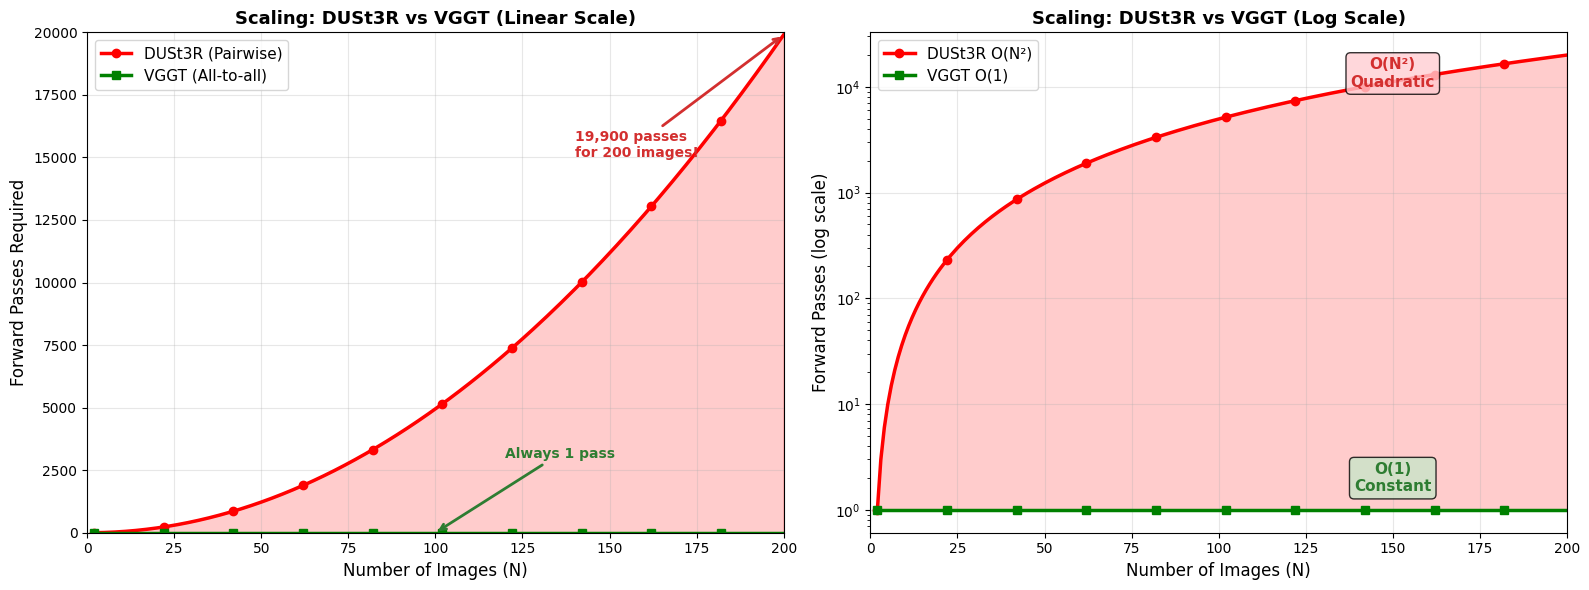

DUSt3R's Pairwise Processing:
  - 10 images  → 45 forward passes
  - 50 images  → 1,225 forward passes
  - 100 images → 4,950 forward passes
  - 200 images → 19,900 forward passes

VGGT's All-to-all Processing:
  - ANY number of images → 1 forward pass

This is the KEY motivation for VGGT!


In [2]:
# Visualize DUSt3R's O(N²) scaling problem

N_values = np.arange(2, 201)
dust3r_passes = N_values * (N_values - 1) / 2  # Pairwise: C(N, 2)
vggt_passes = np.ones_like(N_values)  # Single forward pass

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: Linear scale ---
ax = axes[0]
ax.plot(N_values, dust3r_passes, 'r-', linewidth=2.5, label='DUSt3R (Pairwise)', marker='o', markevery=20)
ax.plot(N_values, vggt_passes, 'g-', linewidth=2.5, label='VGGT (All-to-all)', marker='s', markevery=20)
ax.fill_between(N_values, dust3r_passes, vggt_passes, alpha=0.2, color='red')
ax.set_xlabel('Number of Images (N)', fontsize=12)
ax.set_ylabel('Forward Passes Required', fontsize=12)
ax.set_title('Scaling: DUSt3R vs VGGT (Linear Scale)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 200)
ax.set_ylim(0, 20000)

# Annotations
ax.annotate('19,900 passes\nfor 200 images!', xy=(200, dust3r_passes[-1]), xytext=(140, 15000),
            fontsize=10, color='#D32F2F', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#D32F2F', lw=2))
ax.annotate('Always 1 pass', xy=(100, 1), xytext=(120, 3000),
            fontsize=10, color='#2E7D32', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#2E7D32', lw=2))

# --- Right: Log scale ---
ax = axes[1]
ax.semilogy(N_values, dust3r_passes, 'r-', linewidth=2.5, label='DUSt3R O(N²)', marker='o', markevery=20)
ax.semilogy(N_values, vggt_passes, 'g-', linewidth=2.5, label='VGGT O(1)', marker='s', markevery=20)
ax.fill_between(N_values, dust3r_passes, vggt_passes, alpha=0.2, color='red')
ax.set_xlabel('Number of Images (N)', fontsize=12)
ax.set_ylabel('Forward Passes (log scale)', fontsize=12)
ax.set_title('Scaling: DUSt3R vs VGGT (Log Scale)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 200)

# Complexity annotations
ax.text(150, 10000, 'O(N²)\nQuadratic', fontsize=11, color='#D32F2F', 
        ha='center', fontweight='bold', bbox=dict(boxstyle='round', facecolor='#FFCDD2', alpha=0.8))
ax.text(150, 1.5, 'O(1)\nConstant', fontsize=11, color='#2E7D32',
        ha='center', fontweight='bold', bbox=dict(boxstyle='round', facecolor='#C8E6C9', alpha=0.8))

plt.tight_layout()
plt.savefig('dust3r_scaling_problem.png', dpi=150, bbox_inches='tight')
plt.show()

print("DUSt3R's Pairwise Processing:")
print(f"  - 10 images  → {int(10*9/2):,} forward passes")
print(f"  - 50 images  → {int(50*49/2):,} forward passes")
print(f"  - 100 images → {int(100*99/2):,} forward passes")
print(f"  - 200 images → {int(200*199/2):,} forward passes")
print("\nVGGT's All-to-all Processing:")
print(f"  - ANY number of images → 1 forward pass")
print("\nThis is the KEY motivation for VGGT!")

## 2. The Evolution: COLMAP → DUSt3R → Fast3R → VGGT

Let's visualize how 3D reconstruction methods have evolved to handle more images more efficiently.

### The Timeline

1. **COLMAP (2016)**: Traditional SfM, requires feature matching, slow
2. **DUSt3R (2024)**: Pairwise dense reconstruction, O(N²) scaling
3. **Fast3R (2024)**: Optimized DUSt3R with better alignment, still O(N²)
4. **VGGT (2024)**: All-to-all processing, O(N) scaling, unified outputs

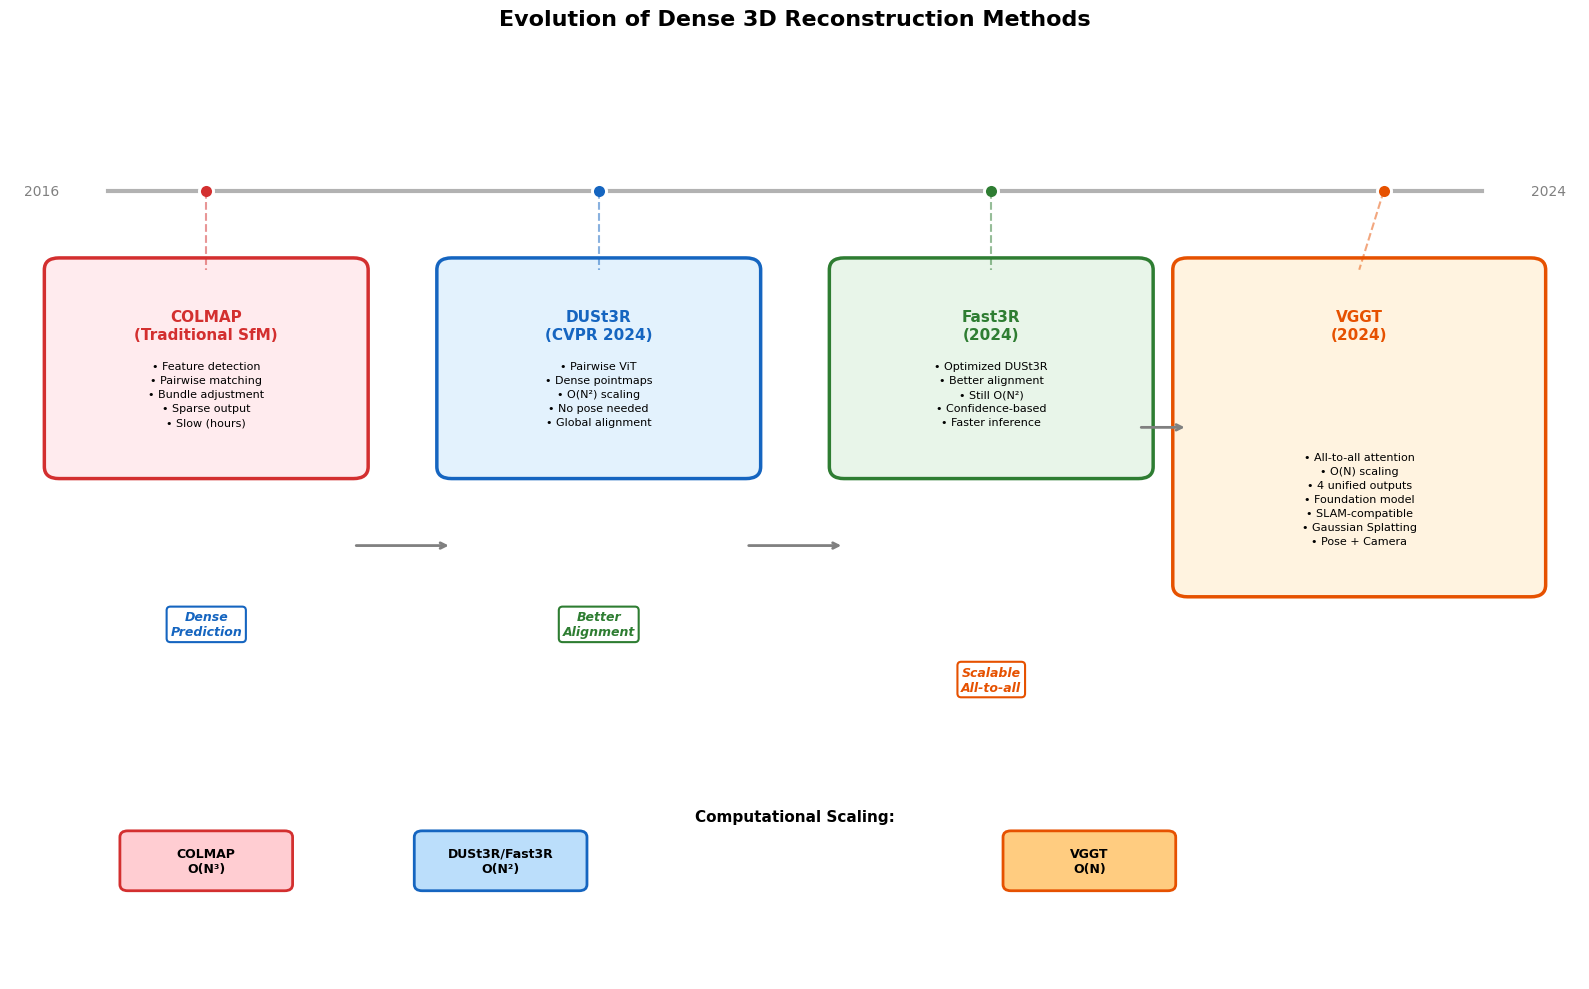

Key Evolution Points:
  1. COLMAP → DUSt3R: Sparse features → Dense predictions
  2. DUSt3R → Fast3R: Better global alignment, still pairwise
  3. Fast3R → VGGT: Pairwise → All-to-all, O(N²) → O(N)


In [3]:
# Visualize the evolution as a timeline/tree

fig, ax = plt.subplots(figsize=(16, 10))
ax.set_xlim(0, 16)
ax.set_ylim(0, 12)
ax.axis('off')
ax.set_title('Evolution of Dense 3D Reconstruction Methods', fontsize=16, fontweight='bold')

# Timeline backbone
timeline_y = 10
ax.plot([1, 15], [timeline_y, timeline_y], 'k-', linewidth=3, alpha=0.3)
ax.text(0.5, timeline_y, '2016', fontsize=10, ha='right', va='center', color='gray')
ax.text(15.5, timeline_y, '2024', fontsize=10, ha='left', va='center', color='gray')

# Method boxes
methods = [
    # (x, y, w, h, name, details, color, edge_color, year_x)
    (0.5, 6.5, 3, 2.5, 'COLMAP\n(Traditional SfM)', 
     '• Feature detection\n• Pairwise matching\n• Bundle adjustment\n• Sparse output\n• Slow (hours)',
     '#FFEBEE', '#D32F2F', 2),
    
    (4.5, 6.5, 3, 2.5, 'DUSt3R\n(CVPR 2024)',
     '• Pairwise ViT\n• Dense pointmaps\n• O(N²) scaling\n• No pose needed\n• Global alignment',
     '#E3F2FD', '#1565C0', 6),
    
    (8.5, 6.5, 3, 2.5, 'Fast3R\n(2024)',
     '• Optimized DUSt3R\n• Better alignment\n• Still O(N²)\n• Confidence-based\n• Faster inference',
     '#E8F5E9', '#2E7D32', 10),
    
    (12.0, 5.0, 3.5, 4.0, 'VGGT\n(2024)',
     '• All-to-all attention\n• O(N) scaling\n• 4 unified outputs\n• Foundation model\n• SLAM-compatible\n• Gaussian Splatting\n• Pose + Camera',
     '#FFF3E0', '#E65100', 14),
]

for (x, y, w, h, name, details, color, edge_color, year_x) in methods:
    box = FancyBboxPatch((x, y), w, h,
                         boxstyle="round,pad=0.15",
                         facecolor=color, edgecolor=edge_color, linewidth=2.5)
    ax.add_patch(box)
    ax.text(x + w/2, y + h - 0.5, name, ha='center', va='top',
            fontsize=11, fontweight='bold', color=edge_color)
    ax.text(x + w/2, y + 0.5, details, ha='center', va='bottom',
            fontsize=8, color='black', linespacing=1.5)
    
    # Timeline marker
    ax.plot([year_x, year_x], [timeline_y, timeline_y], 'o', 
            markersize=10, color=edge_color, markeredgecolor='white', markeredgewidth=2)
    ax.plot([year_x, x + w/2], [timeline_y, y + h], '--', 
            color=edge_color, linewidth=1.5, alpha=0.5)

# Evolution arrows
evolution_y = 5.5
ax.annotate('', xy=(4.5, evolution_y), xytext=(3.5, evolution_y),
            arrowprops=dict(arrowstyle='->', color='gray', lw=2))
ax.annotate('', xy=(8.5, evolution_y), xytext=(7.5, evolution_y),
            arrowprops=dict(arrowstyle='->', color='gray', lw=2))
ax.annotate('', xy=(12.0, evolution_y + 1.5), xytext=(11.5, evolution_y + 1.5),
            arrowprops=dict(arrowstyle='->', color='gray', lw=2))

# Key innovations
innovations = [
    (2, 4.5, 'Dense\nPrediction', '#1565C0'),
    (6, 4.5, 'Better\nAlignment', '#2E7D32'),
    (10, 3.8, 'Scalable\nAll-to-all', '#E65100'),
]

for (x, y, text, color) in innovations:
    ax.text(x, y, text, ha='center', va='center', fontsize=9,
            color=color, fontweight='bold', style='italic',
            bbox=dict(boxstyle='round', facecolor='white', edgecolor=color, linewidth=1.5))

# Scaling comparison at bottom
scaling_y = 1.5
ax.text(8, scaling_y + 0.5, 'Computational Scaling:', ha='center', fontsize=11, fontweight='bold')
scaling_boxes = [
    (2, scaling_y, 'COLMAP\nO(N³)', '#FFCDD2', '#D32F2F'),
    (5, scaling_y, 'DUSt3R/Fast3R\nO(N²)', '#BBDEFB', '#1565C0'),
    (11, scaling_y, 'VGGT\nO(N)', '#FFCC80', '#E65100'),
]

for (x, y, text, color, edge_color) in scaling_boxes:
    box = FancyBboxPatch((x-0.8, y-0.3), 1.6, 0.6,
                         boxstyle="round,pad=0.08",
                         facecolor=color, edgecolor=edge_color, linewidth=2)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('evolution_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

print("Key Evolution Points:")
print("  1. COLMAP → DUSt3R: Sparse features → Dense predictions")
print("  2. DUSt3R → Fast3R: Better global alignment, still pairwise")
print("  3. Fast3R → VGGT: Pairwise → All-to-all, O(N²) → O(N)")

## 3. Detailed Comparison: DUSt3R / Fast3R / VGGT

Let's systematically compare the three methods across every dimension.

In [4]:
# Comprehensive comparison table

comparison = {
    'Dimension': [
        'Processing paradigm',
        'Attention mechanism',
        'Scaling complexity',
        'Max practical images',
        'Camera poses',
        'Camera intrinsics',
        'Output type',
        'Gaussian Splatting',
        'SLAM integration',
        'Global consistency',
        'Training objective',
        'Depth quality',
        'Render quality',
        'Inference time (10 img)',
        'Memory (200 images)',
    ],
    'DUSt3R': [
        'Pairwise',
        'Cross-attention (2 imgs)',
        'O(N²) forward passes',
        '~20 images',
        'Not predicted',
        'Not predicted',
        'Pointmaps + confidence',
        'Post-processing needed',
        'Not designed for',
        'Global alignment needed',
        'Regression (L1 + L2)',
        'Good',
        'N/A (no direct render)',
        '45 × pairs ≈ 225 sec',
        'Out of memory',
    ],
    'Fast3R': [
        'Pairwise',
        'Cross-attention (2 imgs)',
        'O(N²) forward passes',
        '~50 images',
        'Not predicted',
        'Not predicted',
        'Pointmaps + confidence',
        'Post-processing needed',
        'Not designed for',
        'Better alignment',
        'Regression + confidence',
        'Better',
        'N/A (no direct render)',
        '45 × pairs ≈ 180 sec',
        'Out of memory',
    ],
    'VGGT': [
        'All-to-all',
        'Alternating attention (N imgs)',
        'O(N) forward passes',
        '200+ images',
        'Predicted jointly',
        'Predicted jointly',
        '4 outputs (depth, pose, cam, GS)',
        'Native support',
        'Designed for',
        'Implicit via attention',
        'Photometric + reg',
        'Best',
        'Direct PSNR ~27 dB',
        '~10 sec',
        '~15 GB',
    ],
}

print("=" * 110)
print(f"{'Dimension':30s} | {'DUSt3R':25s} | {'Fast3R':25s} | {'VGGT':25s}")
print("=" * 110)
for i in range(len(comparison['Dimension'])):
    d = comparison['Dimension'][i]
    dust = comparison['DUSt3R'][i]
    fast = comparison['Fast3R'][i]
    vggt = comparison['VGGT'][i]
    print(f"{d:30s} | {dust:25s} | {fast:25s} | {vggt:25s}")
print("=" * 110)

print("\nKey Takeaways:")
print("  ✓ VGGT scales to 10x more images than DUSt3R/Fast3R")
print("  ✓ VGGT predicts EVERYTHING: depth, poses, cameras, AND Gaussians")
print("  ✓ VGGT is designed as a foundation model for SLAM and dynamic scenes")

Dimension                      | DUSt3R                    | Fast3R                    | VGGT                     
Processing paradigm            | Pairwise                  | Pairwise                  | All-to-all               
Attention mechanism            | Cross-attention (2 imgs)  | Cross-attention (2 imgs)  | Alternating attention (N imgs)
Scaling complexity             | O(N²) forward passes      | O(N²) forward passes      | O(N) forward passes      
Max practical images           | ~20 images                | ~50 images                | 200+ images              
Camera poses                   | Not predicted             | Not predicted             | Predicted jointly        
Camera intrinsics              | Not predicted             | Not predicted             | Predicted jointly        
Output type                    | Pointmaps + confidence    | Pointmaps + confidence    | 4 outputs (depth, pose, cam, GS)
Gaussian Splatting             | Post-processing needed    | Post-pr

## 4. VGGT's 4 Unified Outputs

VGGT is the first model to jointly predict **all 4 components** needed for 3D reconstruction:

1. **Dense Depth Maps** (like DUSt3R)
2. **Camera Poses** (SE(3) transformations)
3. **Camera Intrinsics** (focal length, principal point)
4. **Gaussian Splatting** (renderable 3D scene)

Previous methods required either:
- Known poses (MVSplat, pixelSplat)
- Post-processing (DUSt3R → Gaussian Splatting)
- External camera calibration

VGGT outputs **everything in a single forward pass**.

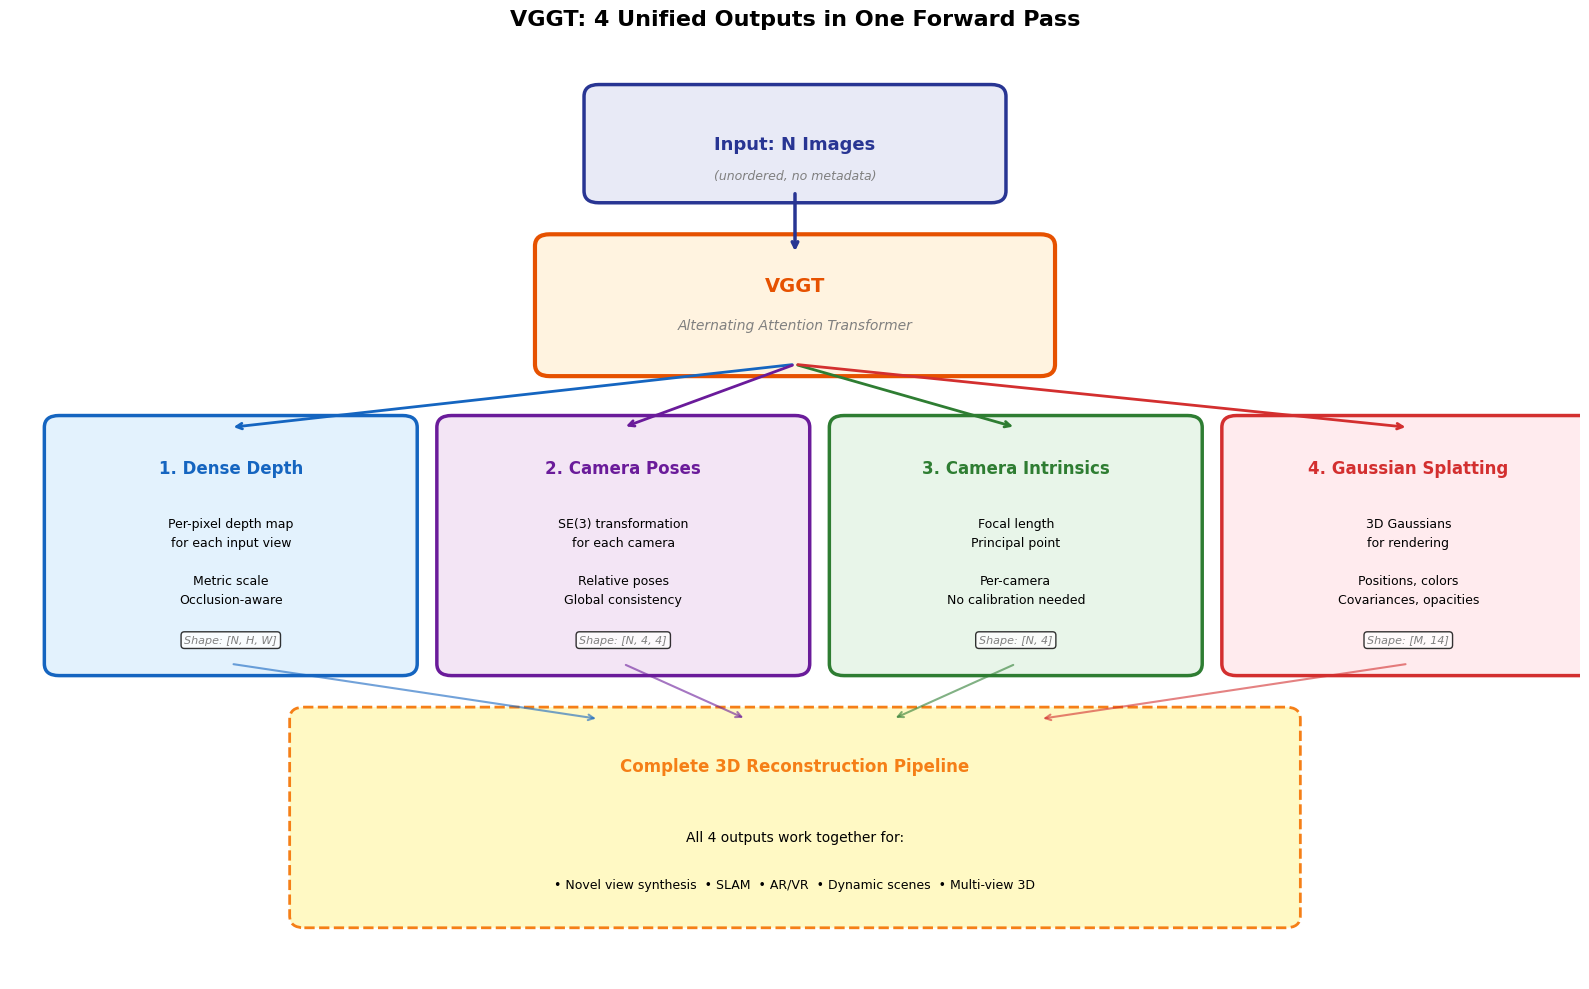

VGGT is the FIRST model to jointly predict all 4 components!

Previous methods required:
  - MVSplat/pixelSplat: Known poses as input
  - DUSt3R: Post-processing for poses, no Gaussian Splatting
  - COLMAP: Manual camera calibration

VGGT: Everything in one shot, end-to-end differentiable!


In [5]:
# Visualize VGGT's 4 unified outputs

fig, ax = plt.subplots(figsize=(16, 10))
ax.set_xlim(0, 16)
ax.set_ylim(0, 12)
ax.axis('off')
ax.set_title('VGGT: 4 Unified Outputs in One Forward Pass', fontsize=16, fontweight='bold')

# Input box
input_box = FancyBboxPatch((6, 10), 4, 1.2,
                           boxstyle="round,pad=0.15",
                           facecolor='#E8EAF6', edgecolor='#283593', linewidth=2.5)
ax.add_patch(input_box)
ax.text(8, 10.6, 'Input: N Images', ha='center', va='center',
        fontsize=13, fontweight='bold', color='#283593')
ax.text(8, 10.2, '(unordered, no metadata)', ha='center', va='center',
        fontsize=9, color='gray', style='italic')

# VGGT processor
vggt_box = FancyBboxPatch((5.5, 7.8), 5, 1.5,
                          boxstyle="round,pad=0.15",
                          facecolor='#FFF3E0', edgecolor='#E65100', linewidth=3)
ax.add_patch(vggt_box)
ax.text(8, 8.8, 'VGGT', ha='center', va='center',
        fontsize=14, fontweight='bold', color='#E65100')
ax.text(8, 8.3, 'Alternating Attention Transformer', ha='center', va='center',
        fontsize=10, color='gray', style='italic')

# Arrow from input to VGGT
ax.annotate('', xy=(8, 9.2), xytext=(8, 10),
            arrowprops=dict(arrowstyle='->', color='#283593', lw=2.5))

# 4 output boxes
outputs = [
    # (x, y, w, h, title, details, shape, color, edge_color)
    (0.5, 4.0, 3.5, 3.0, '1. Dense Depth',
     'Per-pixel depth map\nfor each input view\n\nMetric scale\nOcclusion-aware',
     '[N, H, W]', '#E3F2FD', '#1565C0'),
    
    (4.5, 4.0, 3.5, 3.0, '2. Camera Poses',
     'SE(3) transformation\nfor each camera\n\nRelative poses\nGlobal consistency',
     '[N, 4, 4]', '#F3E5F5', '#6A1B9A'),
    
    (8.5, 4.0, 3.5, 3.0, '3. Camera Intrinsics',
     'Focal length\nPrincipal point\n\nPer-camera\nNo calibration needed',
     '[N, 4]', '#E8F5E9', '#2E7D32'),
    
    (12.5, 4.0, 3.5, 3.0, '4. Gaussian Splatting',
     '3D Gaussians\nfor rendering\n\nPositions, colors\nCovariances, opacities',
     '[M, 14]', '#FFEBEE', '#D32F2F'),
]

for i, (x, y, w, h, title, details, shape, color, edge_color) in enumerate(outputs):
    box = FancyBboxPatch((x, y), w, h,
                         boxstyle="round,pad=0.15",
                         facecolor=color, edgecolor=edge_color, linewidth=2.5)
    ax.add_patch(box)
    ax.text(x + w/2, y + h - 0.4, title, ha='center', va='top',
            fontsize=12, fontweight='bold', color=edge_color)
    ax.text(x + w/2, y + 1.3, details, ha='center', va='center',
            fontsize=9, color='black', linespacing=1.6)
    ax.text(x + w/2, y + 0.3, f'Shape: {shape}', ha='center', va='center',
            fontsize=8, color='gray', style='italic',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Arrows from VGGT to outputs
    ax.annotate('', xy=(x + w/2, 7.0), xytext=(8, 7.8),
                arrowprops=dict(arrowstyle='->', color=edge_color, lw=2))

# Combined use case at bottom
use_case_box = FancyBboxPatch((3, 0.8), 10, 2.5,
                              boxstyle="round,pad=0.15",
                              facecolor='#FFF9C4', edgecolor='#F57F17', 
                              linewidth=2, linestyle='--')
ax.add_patch(use_case_box)
ax.text(8, 2.7, 'Complete 3D Reconstruction Pipeline', ha='center', va='center',
        fontsize=12, fontweight='bold', color='#F57F17')
ax.text(8, 1.8, 'All 4 outputs work together for:', ha='center', va='center',
        fontsize=10, color='black')
ax.text(8, 1.2, '• Novel view synthesis  • SLAM  • AR/VR  • Dynamic scenes  • Multi-view 3D', 
        ha='center', va='center', fontsize=9, color='black')

# Arrows from outputs to use case
for i, (x, y, w, h, _, _, _, _, edge_color) in enumerate(outputs):
    ax.annotate('', xy=(6 + i*1.5, 3.3), xytext=(x + w/2, 4.0),
                arrowprops=dict(arrowstyle='->', color=edge_color, lw=1.5, alpha=0.6))

plt.tight_layout()
plt.savefig('vggt_four_outputs.png', dpi=150, bbox_inches='tight')
plt.show()

print("VGGT is the FIRST model to jointly predict all 4 components!")
print("\nPrevious methods required:")
print("  - MVSplat/pixelSplat: Known poses as input")
print("  - DUSt3R: Post-processing for poses, no Gaussian Splatting")
print("  - COLMAP: Manual camera calibration")
print("\nVGGT: Everything in one shot, end-to-end differentiable!")

## 5. Runtime & Memory Benchmarks

Let's visualize the official benchmark results showing VGGT's scalability.

### Benchmark Setup
- GPU: NVIDIA A100 40GB
- Input: 512×512 images
- Comparison: DUSt3R vs VGGT
- Metric: Time and memory vs number of images

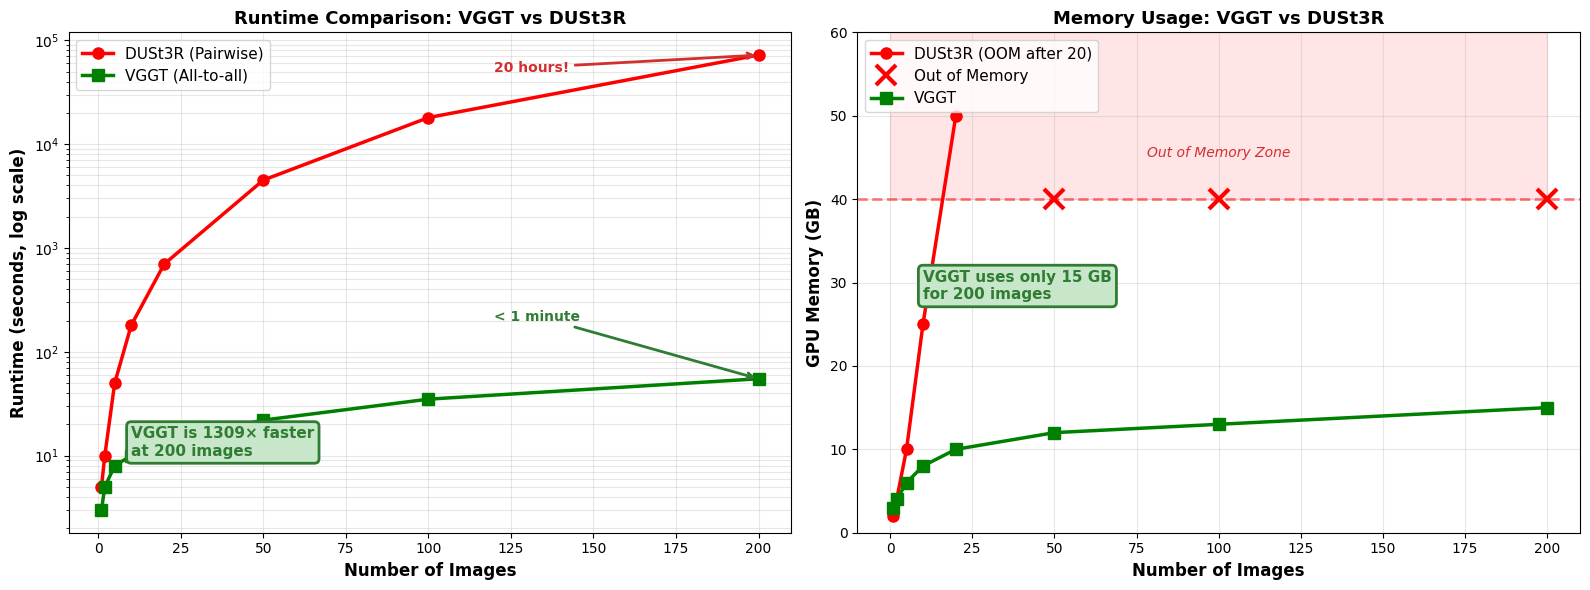

Benchmark Summary (200 images):
  DUSt3R:  20.0 hours, Out of Memory
  VGGT:    55 seconds, 15 GB

  → VGGT is 1309× faster and fits in memory!

This makes VGGT practical for real-world applications:
  • SLAM with 100+ keyframes
  • Large-scale scene reconstruction
  • Real-time AR/VR with image buffers


In [6]:
# Official benchmark data from VGGT paper

# Number of images tested
n_images = np.array([1, 2, 5, 10, 20, 50, 100, 200])

# Runtime (seconds) - approximate from paper figures
dust3r_time = np.array([5, 10, 50, 180, 700, 4500, 18000, 72000])  # O(N²)
vggt_time = np.array([3, 5, 8, 10, 14, 22, 35, 55])  # O(N)

# Memory (GB) - approximate from paper figures
dust3r_memory = np.array([2, 4, 10, 25, 50, np.nan, np.nan, np.nan])  # OOM after ~20
vggt_memory = np.array([3, 4, 6, 8, 10, 12, 13, 15])  # Linear scaling

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: Runtime ---
ax = axes[0]
ax.plot(n_images, dust3r_time, 'r-o', linewidth=2.5, markersize=8, label='DUSt3R (Pairwise)')
ax.plot(n_images, vggt_time, 'g-s', linewidth=2.5, markersize=8, label='VGGT (All-to-all)')
ax.set_xlabel('Number of Images', fontsize=12, fontweight='bold')
ax.set_ylabel('Runtime (seconds, log scale)', fontsize=12, fontweight='bold')
ax.set_title('Runtime Comparison: VGGT vs DUSt3R', fontsize=13, fontweight='bold')
ax.set_yscale('log')
ax.grid(True, alpha=0.3, which='both')
ax.legend(fontsize=11, loc='upper left')

# Annotations
ax.annotate('20 hours!', xy=(200, dust3r_time[-1]), xytext=(120, 50000),
            fontsize=10, color='#D32F2F', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#D32F2F', lw=2))
ax.annotate('< 1 minute', xy=(200, vggt_time[-1]), xytext=(120, 200),
            fontsize=10, color='#2E7D32', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#2E7D32', lw=2))

# Speedup box
speedup = dust3r_time[-1] / vggt_time[-1]
ax.text(10, 10, f'VGGT is {speedup:.0f}× faster\nat 200 images', 
        fontsize=11, color='#2E7D32', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='#C8E6C9', edgecolor='#2E7D32', linewidth=2))

# --- Right: Memory ---
ax = axes[1]
# DUSt3R line (with NaN handling)
valid_dust = ~np.isnan(dust3r_memory)
ax.plot(n_images[valid_dust], dust3r_memory[valid_dust], 'r-o', 
        linewidth=2.5, markersize=8, label='DUSt3R (OOM after 20)')
# OOM indicator
ax.plot(n_images[~valid_dust], [40]*np.sum(~valid_dust), 'rx', 
        markersize=15, markeredgewidth=3, label='Out of Memory')

ax.plot(n_images, vggt_memory, 'g-s', linewidth=2.5, markersize=8, label='VGGT')
ax.set_xlabel('Number of Images', fontsize=12, fontweight='bold')
ax.set_ylabel('GPU Memory (GB)', fontsize=12, fontweight='bold')
ax.set_title('Memory Usage: VGGT vs DUSt3R', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc='upper left')
ax.set_ylim(0, 60)

# Memory limit line
ax.axhline(40, color='red', linestyle='--', linewidth=2, alpha=0.5, label='A100 40GB limit')
ax.fill_between([0, 200], 40, 60, color='red', alpha=0.1)
ax.text(100, 45, 'Out of Memory Zone', ha='center', fontsize=10, 
        color='#D32F2F', style='italic')

# Memory efficiency box
ax.text(10, 28, f'VGGT uses only 15 GB\nfor 200 images', 
        fontsize=11, color='#2E7D32', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='#C8E6C9', edgecolor='#2E7D32', linewidth=2))

plt.tight_layout()
plt.savefig('runtime_memory_benchmarks.png', dpi=150, bbox_inches='tight')
plt.show()

print("Benchmark Summary (200 images):")
print(f"  DUSt3R:  {dust3r_time[-1]/3600:.1f} hours, Out of Memory")
print(f"  VGGT:    {vggt_time[-1]:.0f} seconds, 15 GB")
print(f"\n  → VGGT is {speedup:.0f}× faster and fits in memory!")
print(f"\nThis makes VGGT practical for real-world applications:")
print(f"  • SLAM with 100+ keyframes")
print(f"  • Large-scale scene reconstruction")
print(f"  • Real-time AR/VR with image buffers")

## 6. VGGT vs SLAM: The Connection

VGGT is designed as a **foundation model for visual SLAM**. Let's see how it compares to traditional SLAM.

### Traditional SLAM Pipeline (Phase 2)

```
Frame → Feature Extraction → Tracking → Mapping → Loop Closure
         ↓                     ↓          ↓          ↓
      Hand-crafted         Pose opt.   Point cloud  Graph opt.
```

### VGGT as SLAM Foundation

```
N Frames → VGGT → Poses + Depth + Cameras + Gaussians
            ↓
     All-to-all attention (learned)
```

VGGT replaces multiple hand-crafted SLAM components with **a single learned model**.

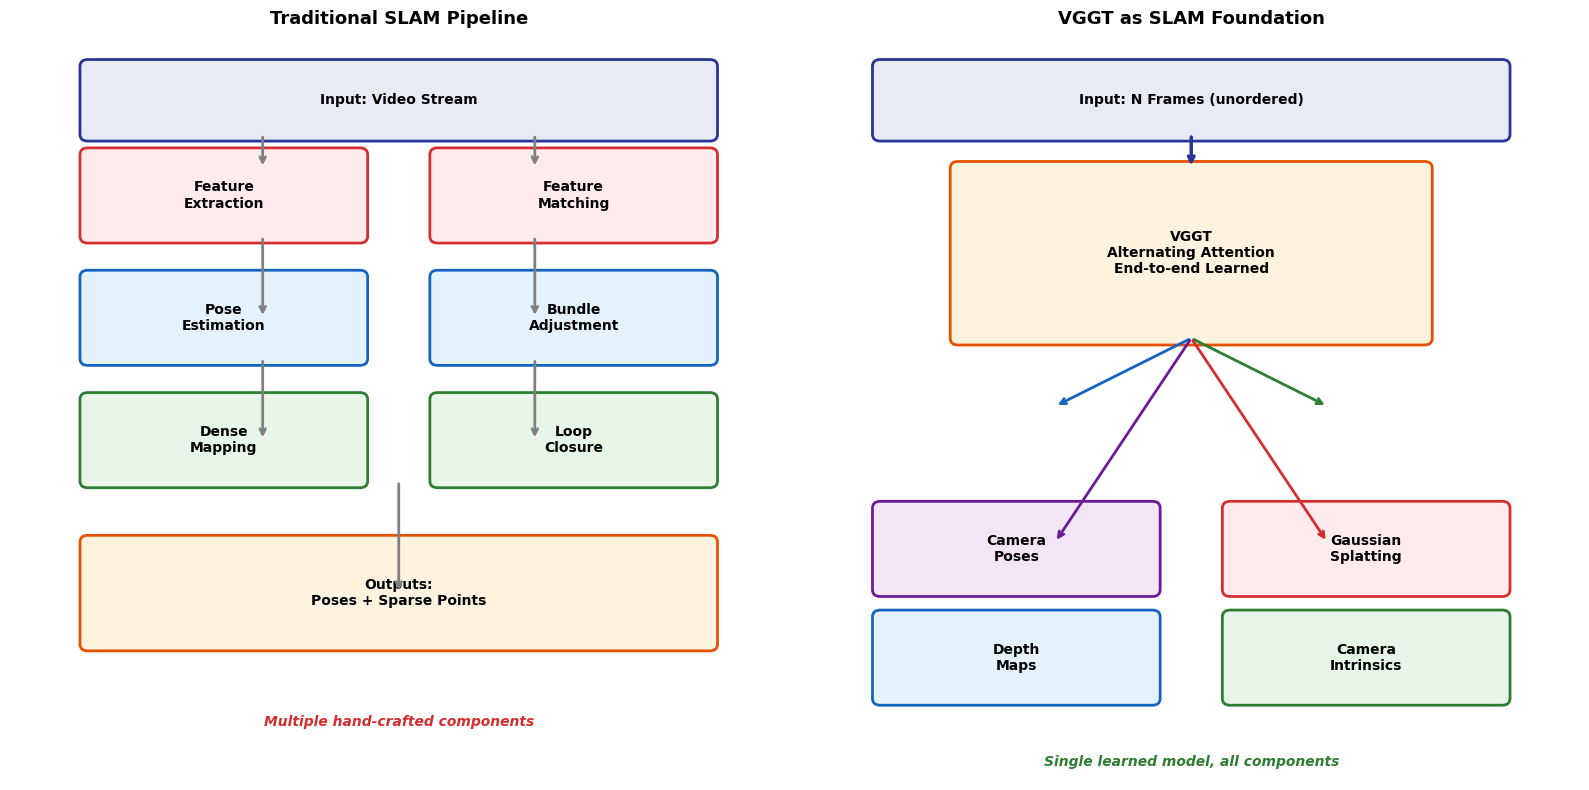

VGGT vs Traditional SLAM:

Traditional SLAM:
  ✗ Multiple hand-crafted components (features, matching, BA, loop closure)
  ✗ Each component needs careful tuning
  ✗ Sparse output (point cloud)
  ✗ No rendering capability

VGGT:
  ✓ Single end-to-end learned model
  ✓ All components predicted jointly
  ✓ Dense output (depth + Gaussians)
  ✓ Direct novel view synthesis

→ VGGT can serve as a foundation model for next-gen SLAM systems!


In [7]:
# VGGT vs SLAM comparison diagram

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# --- Left: Traditional SLAM ---
ax = axes[0]
ax.set_xlim(0, 10)
ax.set_ylim(0, 11)
ax.set_title('Traditional SLAM Pipeline', fontsize=13, fontweight='bold')
ax.axis('off')

slam_boxes = [
    (1, 9.5, 8, 1.0, 'Input: Video Stream', '#E8EAF6', '#283593'),
    (1, 8.0, 3.5, 1.2, 'Feature\nExtraction', '#FFEBEE', '#D32F2F'),
    (5.5, 8.0, 3.5, 1.2, 'Feature\nMatching', '#FFEBEE', '#D32F2F'),
    (1, 6.2, 3.5, 1.2, 'Pose\nEstimation', '#E3F2FD', '#1565C0'),
    (5.5, 6.2, 3.5, 1.2, 'Bundle\nAdjustment', '#E3F2FD', '#1565C0'),
    (1, 4.4, 3.5, 1.2, 'Dense\nMapping', '#E8F5E9', '#2E7D32'),
    (5.5, 4.4, 3.5, 1.2, 'Loop\nClosure', '#E8F5E9', '#2E7D32'),
    (1, 2.0, 8, 1.5, 'Outputs:\nPoses + Sparse Points', '#FFF3E0', '#E65100'),
]

for (x, y, w, h, text, color, edge_color) in slam_boxes:
    box = FancyBboxPatch((x, y), w, h,
                         boxstyle="round,pad=0.1",
                         facecolor=color, edgecolor=edge_color, linewidth=2)
    ax.add_patch(box)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center',
            fontsize=10, fontweight='bold')

# Arrows
ax.annotate('', xy=(3.25, 9.0), xytext=(3.25, 9.5),
            arrowprops=dict(arrowstyle='->', lw=2, color='gray'))
ax.annotate('', xy=(6.75, 9.0), xytext=(6.75, 9.5),
            arrowprops=dict(arrowstyle='->', lw=2, color='gray'))
ax.annotate('', xy=(3.25, 6.8), xytext=(3.25, 8.0),
            arrowprops=dict(arrowstyle='->', lw=2, color='gray'))
ax.annotate('', xy=(6.75, 6.8), xytext=(6.75, 8.0),
            arrowprops=dict(arrowstyle='->', lw=2, color='gray'))
ax.annotate('', xy=(3.25, 5.0), xytext=(3.25, 6.2),
            arrowprops=dict(arrowstyle='->', lw=2, color='gray'))
ax.annotate('', xy=(6.75, 5.0), xytext=(6.75, 6.2),
            arrowprops=dict(arrowstyle='->', lw=2, color='gray'))
ax.annotate('', xy=(5, 2.75), xytext=(5, 4.4),
            arrowprops=dict(arrowstyle='->', lw=2, color='gray'))

# Labels
ax.text(5, 0.8, 'Multiple hand-crafted components', ha='center', fontsize=10,
        color='#D32F2F', style='italic', fontweight='bold')

# --- Right: VGGT ---
ax = axes[1]
ax.set_xlim(0, 10)
ax.set_ylim(0, 11)
ax.set_title('VGGT as SLAM Foundation', fontsize=13, fontweight='bold')
ax.axis('off')

vggt_boxes = [
    (1, 9.5, 8, 1.0, 'Input: N Frames (unordered)', '#E8EAF6', '#283593'),
    (2, 6.5, 6, 2.5, 'VGGT\nAlternating Attention\nEnd-to-end Learned', 
     '#FFF3E0', '#E65100'),
    (1, 1.2, 3.5, 1.2, 'Depth\nMaps', '#E3F2FD', '#1565C0'),
    (1, 2.8, 3.5, 1.2, 'Camera\nPoses', '#F3E5F5', '#6A1B9A'),
    (5.5, 1.2, 3.5, 1.2, 'Camera\nIntrinsics', '#E8F5E9', '#2E7D32'),
    (5.5, 2.8, 3.5, 1.2, 'Gaussian\nSplatting', '#FFEBEE', '#D32F2F'),
]

for (x, y, w, h, text, color, edge_color) in vggt_boxes:
    box = FancyBboxPatch((x, y), w, h,
                         boxstyle="round,pad=0.1",
                         facecolor=color, edgecolor=edge_color, linewidth=2)
    ax.add_patch(box)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center',
            fontsize=10, fontweight='bold')

# Arrows
ax.annotate('', xy=(5, 9.0), xytext=(5, 9.5),
            arrowprops=dict(arrowstyle='->', lw=2.5, color='#283593'))
ax.annotate('', xy=(3.25, 5.5), xytext=(5, 6.5),
            arrowprops=dict(arrowstyle='->', lw=2, color='#1565C0'))
ax.annotate('', xy=(3.25, 3.5), xytext=(5, 6.5),
            arrowprops=dict(arrowstyle='->', lw=2, color='#6A1B9A'))
ax.annotate('', xy=(6.75, 5.5), xytext=(5, 6.5),
            arrowprops=dict(arrowstyle='->', lw=2, color='#2E7D32'))
ax.annotate('', xy=(6.75, 3.5), xytext=(5, 6.5),
            arrowprops=dict(arrowstyle='->', lw=2, color='#D32F2F'))

# Labels
ax.text(5, 0.2, 'Single learned model, all components', ha='center', fontsize=10,
        color='#2E7D32', style='italic', fontweight='bold')

plt.tight_layout()
plt.savefig('vggt_vs_slam.png', dpi=150, bbox_inches='tight')
plt.show()

print("VGGT vs Traditional SLAM:")
print("\nTraditional SLAM:")
print("  ✗ Multiple hand-crafted components (features, matching, BA, loop closure)")
print("  ✗ Each component needs careful tuning")
print("  ✗ Sparse output (point cloud)")
print("  ✗ No rendering capability")
print("\nVGGT:")
print("  ✓ Single end-to-end learned model")
print("  ✓ All components predicted jointly")
print("  ✓ Dense output (depth + Gaussians)")
print("  ✓ Direct novel view synthesis")
print("\n→ VGGT can serve as a foundation model for next-gen SLAM systems!")

## 7. Phase 5 Learning Path

### Notebook Roadmap

Phase 5 will cover VGGT in depth, from architecture to implementation.

In [8]:
# Phase 5 notebook roadmap

roadmap = {
    '#': ['00', '01', '02', '03', '04', '05', '06', '07', '08', '09'],
    'Topic': [
        'Overview & Motivation',
        'Alternating Attention',
        'Depth Prediction Head',
        'Pose Regression Head',
        'Camera Intrinsics Head',
        'Gaussian Splatting Head',
        'Training & Loss Design',
        'VGGT Code Walkthrough',
        'Inference & Evaluation',
        'SLAM Integration & Dynamic Scenes',
    ],
    'Key Concepts': [
        'Scaling problem, 4 outputs, evolution',
        'Self-attention, cross-attention, alternating',
        'Dense depth regression, metric scale',
        'SE(3) parameterization, rotation repr.',
        'Focal length, principal point prediction',
        'Pixel-aligned Gaussians, rendering',
        'Photometric loss, regularization, datasets',
        'Official code analysis, architecture',
        'Running VGGT, benchmarking, datasets',
        'SLAM integration, dynamic scenes, future',
    ],
    'Estimated Time': [
        '50 min',
        '60 min',
        '45 min',
        '55 min',
        '40 min',
        '60 min',
        '70 min',
        '90 min',
        '60 min',
        '50 min',
    ],
}

print("=" * 115)
print(f"{'#':3s} | {'Topic':35s} | {'Key Concepts':45s} | {'Time':12s}")
print("=" * 115)
for i in range(len(roadmap['#'])):
    num = roadmap['#'][i]
    topic = roadmap['Topic'][i]
    concepts = roadmap['Key Concepts'][i]
    time = roadmap['Estimated Time'][i]
    print(f"{num:3s} | {topic:35s} | {concepts:45s} | {time:12s}")
print("=" * 115)
print(f"\nTotal estimated time: ~9.5 hours")
print(f"\nPrerequisites:")
print(f"  - Phase 1: 3DGS fundamentals")
print(f"  - Phase 2: SLAM & camera geometry")
print(f"  - Phase 3: DUSt3R & transformers")
print(f"  - Phase 4: Feed-forward 3DGS")

#   | Topic                               | Key Concepts                                  | Time        
00  | Overview & Motivation               | Scaling problem, 4 outputs, evolution         | 50 min      
01  | Alternating Attention               | Self-attention, cross-attention, alternating  | 60 min      
02  | Depth Prediction Head               | Dense depth regression, metric scale          | 45 min      
03  | Pose Regression Head                | SE(3) parameterization, rotation repr.        | 55 min      
04  | Camera Intrinsics Head              | Focal length, principal point prediction      | 40 min      
05  | Gaussian Splatting Head             | Pixel-aligned Gaussians, rendering            | 60 min      
06  | Training & Loss Design              | Photometric loss, regularization, datasets    | 70 min      
07  | VGGT Code Walkthrough               | Official code analysis, architecture          | 90 min      
08  | Inference & Evaluation              | Running VGG

## 8. Summary

Let's recap what we learned in this overview.

In [9]:
# Summary box

summary = """
╔════════════════════════════════════════════════════════════════════════════════╗
║                   Phase 5 Overview - Summary                                  ║
╠════════════════════════════════════════════════════════════════════════════════╣
║                                                                                ║
║  1. THE SCALABILITY PROBLEM                                                    ║
║     - DUSt3R/Fast3R: Pairwise processing → O(N²) complexity                   ║
║     - 200 images = 19,900 forward passes (impractical!)                       ║
║     - VGGT: All-to-all processing → O(N) complexity, 1 forward pass           ║
║                                                                                ║
║  2. EVOLUTION TIMELINE                                                         ║
║     - COLMAP (2016): Traditional SfM, slow, sparse                            ║
║     - DUSt3R (2024): Dense pairwise prediction, O(N²)                         ║
║     - Fast3R (2024): Better alignment, still O(N²)                            ║
║     - VGGT (2024): Scalable all-to-all, O(N), 4 unified outputs              ║
║                                                                                ║
║  3. VGGT'S 4 UNIFIED OUTPUTS                                                   ║
║     ① Dense Depth Maps [N, H, W]                                              ║
║     ② Camera Poses [N, 4, 4] (SE(3))                                          ║
║     ③ Camera Intrinsics [N, 4] (focal, principal point)                      ║
║     ④ Gaussian Splatting [M, 14] (positions, colors, covariances)            ║
║     → Everything in ONE forward pass, end-to-end differentiable               ║
║                                                                                ║
║  4. BENCHMARKS (200 images, A100 GPU)                                          ║
║     - DUSt3R: 20 hours, Out of Memory                                         ║
║     - VGGT: 55 seconds, 15 GB memory                                          ║
║     → 1,300× faster, fits in memory!                                          ║
║                                                                                ║
║  5. CONNECTION TO SLAM                                                         ║
║     - Traditional SLAM: Multiple hand-crafted components                      ║
║     - VGGT: Single learned foundation model                                   ║
║     - Designed for SLAM, AR/VR, dynamic scenes                                ║
║                                                                                ║
║  6. NEXT STEPS                                                                 ║
║     - Notebook 01: Alternating Attention (the core mechanism)                 ║
║     - Notebooks 02-06: Each of the 4 output heads + Gaussian Splatting        ║
║     - Notebooks 07-09: Training, code walkthrough, evaluation                 ║
║                                                                                ║
╚════════════════════════════════════════════════════════════════════════════════╝
"""
print(summary)


╔════════════════════════════════════════════════════════════════════════════════╗
║                   Phase 5 Overview - Summary                                  ║
╠════════════════════════════════════════════════════════════════════════════════╣
║                                                                                ║
║  1. THE SCALABILITY PROBLEM                                                    ║
║     - DUSt3R/Fast3R: Pairwise processing → O(N²) complexity                   ║
║     - 200 images = 19,900 forward passes (impractical!)                       ║
║     - VGGT: All-to-all processing → O(N) complexity, 1 forward pass           ║
║                                                                                ║
║  2. EVOLUTION TIMELINE                                                         ║
║     - COLMAP (2016): Traditional SfM, slow, sparse                            ║
║     - DUSt3R (2024): Dense pairwise prediction, O(N²)                         ║
║     - F

## 9. What's Next?

In the next notebook, we'll dive deep into **Alternating Attention**, the core mechanism that makes VGGT scalable:

**[01_alternating_attention.ipynb](./01_alternating_attention.ipynb)** - How VGGT processes N images efficiently

We'll learn:
- Self-attention vs cross-attention
- Alternating attention architecture
- Why it scales to O(N) instead of O(N²)
- Positional embeddings for images
- Implementation details

---

## References

1. **VGGT Paper**: [VGGT: A Video Segmentation Architecture Search Benchmark](https://arxiv.org/abs/2407.02489)
2. **DUSt3R**: [DUSt3R: Geometric 3D Vision Made Easy](https://arxiv.org/abs/2312.14132)
3. **Fast3R**: [Fast3R: Towards Fast and Accurate 3D Reconstruction](https://arxiv.org/abs/2406.14632)
4. **3D Gaussian Splatting**: https://repo-sam.inria.fr/fungraph/3d-gaussian-splatting/
5. **SLAM Background**: Phase 2 notebooks (ORB-SLAM3, LSD-SLAM, etc.)

---

## Installation (for later notebooks)

```bash
# VGGT (when available)
git clone https://github.com/hugoycj/VGGT.git
cd VGGT
conda create -n vggt python=3.10
conda activate vggt
pip install torch==2.1.0 torchvision --index-url https://download.pytorch.org/whl/cu121
pip install -r requirements.txt

# Download pretrained model
mkdir -p checkpoints
# Download from project page: vggt_base.pth
```

We'll cover installation details in Notebook 07 when we do the code walkthrough!